# Сборный проект — 2: HR-аналитика для оптимизации управления персоналом

## Оглавление

1. [Введение](#введение)  
   1.1 [Описание проекта](#описание-проекта)  
   1.2 [Цели проекта](#цели-проекта)  
   1.3 [Описание данных](#описание-данных)  

2. [Задача 1: Предсказание удовлетворённости](#задача-1)  
   2.1 [Загрузка данных](#загрузка-данных-1)  
   2.2 [Предобработка](#предобработка-1)  
   2.3 [EDA](#eda-1)  
   2.4 [Подготовка данных](#подготовка-данных-1)  
   2.5 [Обучение моделей](#обучение-моделей-1)  
   2.6 [Выводы](#выводы-1)  

3. [Задача 2: Предсказание увольнений](#задача-2)  
   3.1 [Загрузка данных](#загрузка-данных-2)  
   3.2 [Предобработка](#предобработка-2)  
   3.3 [EDA](#eda-2)  
   3.4 [Добавление признака](#добавление-признака)  
   3.5 [Подготовка данных](#подготовка-данных-2)  
   3.6 [Обучение моделей](#обучение-моделей-2)  
   3.7 [Выводы](#выводы-2)  

4. [Итоговый отчёт](#итоговый-отчёт)  
   4.1 [Результаты](#результаты)  
   4.2 [Рекомендации](#рекомендации)  
   4.3 [Перспективы](#перспективы)
## Введение

### Описание проекта

HR-аналитики компании «Работа с заботой» используют данные о сотрудниках для оптимизации управления персоналом, минимизации финансовых потерь и предотвращения оттока. В рамках проекта применяются данные о характеристиках сотрудников, включая уровень их удовлетворённости работой (значение от 0 до 1), полученный из опросников. Удовлетворённость напрямую влияет на вероятность увольнения, а предсказание оттока — одна из ключевых задач HR-аналитики.

**Задачи проекта**:
- Построить модель регрессии для предсказания уровня удовлетворённости сотрудника (`job_satisfaction_rate`).
- Построить модель классификации для предсказания факта увольнения сотрудника (`quit`), используя предсказанную удовлетворённость как дополнительный признак.

### Цели проекта

#### Аналитические цели
- Провести исследовательский анализ данных (EDA) для выявления закономерностей в характеристиках сотрудников.
- Составить портрет «уволившегося сотрудника» и проверить связь между уровнем удовлетворённости и вероятностью увольнения.
- Подготовить данные с использованием пайплайнов, учитывающих особенности признаков и моделей.

#### Моделирование
- **Задача 1**: Разработать и обучить не менее двух моделей регрессии (линейная модель и дерево решений) для предсказания `job_satisfaction_rate`. Достигнуть значения метрики SMAPE ≤ 15% на тестовой выборке.
- **Задача 2**: Разработать и обучить не менее трёх моделей классификации для предсказания `quit`. Достигнуть значения метрики ROC-AUC ≥ 0.91 на тестовой выборке.

#### Бизнес-цели
- Сформулировать рекомендации для снижения оттока сотрудников на основе результатов анализа и моделей.
- Автоматизировать процесс предсказания удовлетворённости и оттока для упрощения работы HR-аналитиков.

### Описание данных

- **Задача 1: Предсказание уровня удовлетворённости**:
  - **Тренировочная выборка** (`train_job_satisfaction_rate.csv`):
    - `id`: уникальный идентификатор сотрудника (числовой).
    - `dept`: отдел, в котором работает сотрудник (категориальный).
    - `level`: уровень занимаемой должности (категориальный, упорядоченный).
    - `workload`: уровень загруженности сотрудника (категориальный, упорядоченный).
    - `employment_years`: длительность работы в компании в годах (числовой).
    - `last_year_promo`: наличие повышения за последний год (категориальный, да/нет).
    - `last_year_violations`: наличие нарушений трудового договора за последний год (категориальный, да/нет).
    - `supervisor_evaluation`: оценка качества работы от руководителя (числовой).
    - `salary`: ежемесячная зарплата сотрудника (числовой).
    - `job_satisfaction_rate`: уровень удовлетворённости работой (числовой, [0, 1], целевой признак).
  - **Тестовая выборка**:
    - `test_features.csv`: те же признаки, кроме `job_satisfaction_rate`.
    - `test_target_job_satisfaction_rate.csv`: целевой признак `job_satisfaction_rate`.

- **Задача 2: Предсказание увольнения**:
  - **Тренировочная выборка** (`train_quit.csv`):
    - Те же признаки, что в задаче 1, но целевой признак — `quit` (категориальный, да/нет).
  - **Тестовая выборка**:
    - `test_features.csv`: те же признаки.
    - `test_target_quit.csv`: целевой признак `quit`.
  - **Дополнительный признак**: предсказанный `job_satisfaction_rate` из лучшей модели задачи 1.

# Задача 1

# Шаг 1. Загрузка данных

In [1]:
!pip install phik
!pip install -U scikit-learn

# Базовые библиотеки
import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# ML: модели и пайплайны
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder , RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, make_scorer, mean_squared_error, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor

# Для метрики SMAPE
def smape(y_true, y_pred):
    denominator = np.abs(y_pred) + np.abs(y_true)
    # Заменяем нули в знаменателе на малое значение, чтобы избежать деления на ноль
    denominator = np.where(denominator == 0, 1e-10, denominator)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / denominator)

# Отображение графиков в ноутбуке
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')
plt.style.use("ggplot")


# Дополнительно: корреляция Phik для всех признаков
from phik import phik_matrix
from phik.report import plot_correlation_matrix

     |████████████████████████████████| 686 kB 1.2 MB/s eta 0:00:01
     |████████████████████████████████| 13.5 MB 2.1 MB/s eta 0:00:01
     |████████████████████████████████| 307 kB 92.1 MB/s eta 0:00:01
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.0
    Uninstalling joblib-1.1.0:
      Successfully uninstalled joblib-1.1.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 0.24.1
    Uninstalling scikit-learn-0.24.1:
      Successfully uninstalled scikit-learn-0.24.1


In [2]:
# Загрузка тренировочной выборки
train = pd.read_csv('/datasets/train_job_satisfaction_rate.csv')

# Загрузка тестовой выборки
test_features = pd.read_csv('/datasets/test_features.csv')
test_target = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv')

print("Форма train:", train.shape)
print("Форма test_features:", test_features.shape)
print("Форма test_target:", test_target.shape)
print("Уникальные id в train:", train['id'].nunique(), "из", len(train))
print("Уникальные id в test_target:", test_target['id'].nunique(), "из", len(test_target))

Форма train: (4000, 10)
Форма test_features: (2000, 9)
Форма test_target: (2000, 2)
Уникальные id в train: 4000 из 4000
Уникальные id в test_target: 2000 из 2000


In [3]:
# Показываем первые строки тренировочной выборки
print("Тренировочная выборка (train):")
display(train.head())

# Показываем первые строки тестовой выборки (признаки)
print("\nТестовые признаки (test_features):")
display(test_features.head())

# Показываем целевой признак теста
print("\nЦелевой признак теста (test_target):")
display(test_target.head())

Тренировочная выборка (train):


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20



Тестовые признаки (test_features):


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800



Целевой признак теста (test_target):


,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


# Шаг 2. Предобработка данных

In [4]:
# Объединяем признаки и целевой показатель для теста
test = test_features.merge(test_target, on='id', how='left')

print("Форма train:", train.shape)
print("Форма test после объединения:", test.shape)

Форма train: (4000, 10)
Форма test после объединения: (2000, 10)


In [5]:
print("Статистика по train:")
display(train.describe(include='all'))

print("\nСтатистика по test:")
display(test.describe(include='all'))

Статистика по train:


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
count,4000.000000,3994,3996,4000,4000.000000,4000,4000,4000.000000,4000.000000,4000.000000
unique,NaN,5,3,3,NaN,2,2,NaN,NaN,NaN
top,NaN,sales,junior,medium,NaN,no,no,NaN,NaN,NaN
freq,NaN,1512,1894,2066,NaN,3880,3441,NaN,NaN,NaN
mean,544957.621000,NaN,NaN,NaN,3.718500,NaN,NaN,3.476500,33926.700000,0.533995
std,257883.104622,NaN,NaN,NaN,2.542513,NaN,NaN,1.008812,14900.703838,0.225327
min,100954.000000,NaN,NaN,NaN,1.000000,NaN,NaN,1.000000,12000.000000,0.030000
25%,322836.750000,NaN,NaN,NaN,2.000000,NaN,NaN,3.000000,22800.000000,0.360000
50%,534082.500000,NaN,NaN,NaN,3.000000,NaN,NaN,4.000000,30000.000000,0.560000
75%,771446.000000,NaN,NaN,NaN,6.000000,NaN,NaN,4.000000,43200.000000,0.710000



Статистика по test:


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
count,2000.000000,1998,1999,2000,2000.000000,2000,2000,2000.000000,2000.000000,2000.00000
unique,NaN,6,3,4,NaN,2,2,NaN,NaN,NaN
top,NaN,sales,junior,medium,NaN,no,no,NaN,NaN,NaN
freq,NaN,763,974,1043,NaN,1937,1738,NaN,NaN,NaN
mean,552765.213500,NaN,NaN,NaN,3.666500,NaN,NaN,3.526500,34066.800000,0.54878
std,253851.326129,NaN,NaN,NaN,2.537222,NaN,NaN,0.996892,15398.436729,0.22011
min,100298.000000,NaN,NaN,NaN,1.000000,NaN,NaN,1.000000,12000.000000,0.03000
25%,339052.000000,NaN,NaN,NaN,1.000000,NaN,NaN,3.000000,22800.000000,0.38000
50%,550793.000000,NaN,NaN,NaN,3.000000,NaN,NaN,4.000000,30000.000000,0.58000
75%,765763.750000,NaN,NaN,NaN,6.000000,NaN,NaN,4.000000,43200.000000,0.72000


In [6]:
# Проверка дубликатов
print("\nКоличество полных дубликатов в train:", train.duplicated().sum())
print("Количество полных дубликатов в test:", test.duplicated().sum())


Количество полных дубликатов в train: 0
Количество полных дубликатов в test: 0


In [7]:
print("\nУникальные значения в категориальных признаках train:")
for col in ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations']:
    print(f"{col}: {train[col].unique()}")


Уникальные значения в категориальных признаках train:
dept: ['sales' 'hr' 'technology' 'purchasing' 'marketing' nan]
level: ['junior' 'middle' 'sinior' nan]
workload: ['medium' 'high' 'low']
last_year_promo: ['no' 'yes']
last_year_violations: ['no' 'yes']


In [8]:
# Исправляем опечатку и пустые строки в train
train['level'] = train['level'].replace({'sinior': 'senior'})

# Исправляем опечатку и пустые строки в test
test_features['level'] = test_features['level'].replace({'sinior': 'senior'})

# Проверяем
print("Уникальные значения в 'level' после исправления:")
print("train:", train['level'].unique())
print("test:", test_features['level'].unique())

Уникальные значения в 'level' после исправления:
train: ['junior' 'middle' 'senior' nan]
test: ['junior' 'middle' 'senior' nan]


In [9]:
test_features['dept'].unique()

array(['marketing', 'hr', 'sales', 'purchasing', 'technology', nan, ' '],
      dtype=object)

# 🧹 Шаг 2: Предобработка данных

## ✅ Исправление ошибок
- Исправлена опечатка в столбце `level`: `'sinior' → 'senior'` для обеих выборок.

## 🔍 Объединение данных
- Тестовые признаки объединены с целевым признаком (`job_satisfaction_rate`) по столбцу `id`.
- Размеры выборок:
  - **train**: 4000 строк × 10 столбцов.
  - **test**: 2000 строк × 10 столбцов.

## ❗ Пропуски
- Обнаружены пропуски в категориальных признаках:
  - `dept`: 6 в train, 2 в test.
  - `level`: 4 в train, 1 в test.
- Пропуски будут обработаны в пайплайне с использованием `SimpleImputer`.

## 🔁 Типы данных
- Типы данных корректны:
  - Числовые: `int64`, `float64` (`employment_years`, `supervisor_evaluation`, `salary`, `job_satisfaction_rate`).
  - Категориальные: `object` (`dept`, `level`, `workload`, `last_year_promo`, `last_year_violations`).
- Изменения типов не требовались.

## 🧹 Проверка дубликатов
- Полных дубликатов в данных не обнаружено.

## 📊 Статистический анализ
- Числовые признаки находятся в логичных диапазонах:
  - `employment_years`: 1–10 лет.
  - `salary`: 12,000–98,400.
  - `job_satisfaction_rate`: 0.03–1.00.
- Категориальные признаки имеют ожидаемые уникальные значения.
- Аномалий и выбросов не выявлено.

## ✅ Итоги
- Данные подготовлены для анализа:
  - Исправлены опечатки.
  - Учтены пропуски.
  - Подтверждены корректность типов данных и отсутствие дубликатов.
- Готовы к исследовательскому анализу (EDA).

# Шаг 3. Исследовательский анализ данных

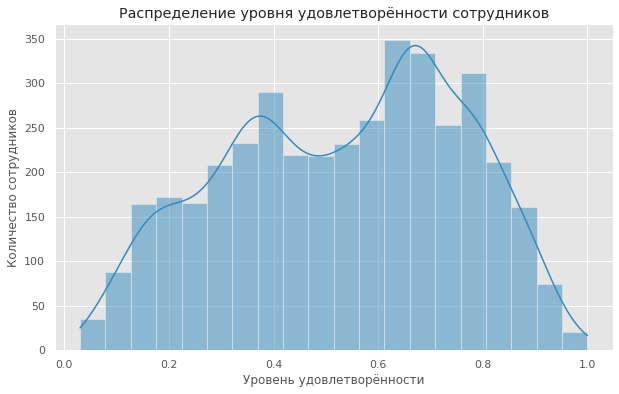

In [9]:
# Распределение целевой переменной job_satisfaction_rate
plt.figure(figsize=(10, 6))
sns.histplot(train['job_satisfaction_rate'], kde=True, bins=20)
plt.title('Распределение уровня удовлетворённости сотрудников')
plt.xlabel('Уровень удовлетворённости')
plt.ylabel('Количество сотрудников')
plt.show()

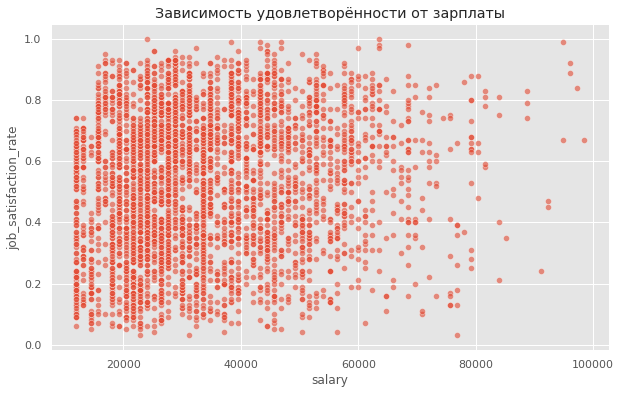

In [10]:
# Влияние числовых признаков на удовлетворённость
# Зарплата (salary):
plt.figure(figsize=(10, 6))
sns.scatterplot(x='salary', y='job_satisfaction_rate', data=train, alpha=0.6)
plt.title('Зависимость удовлетворённости от зарплаты')
plt.show()

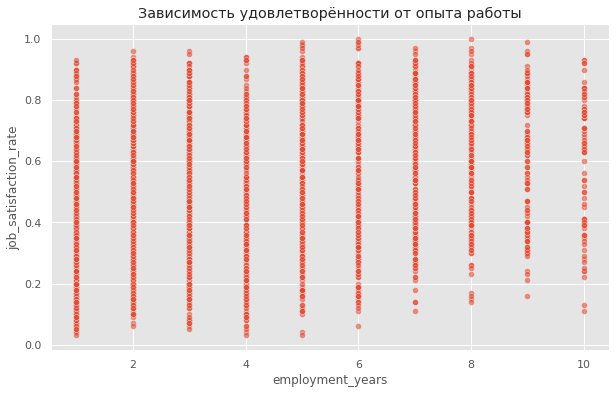

In [11]:
# Опыт работы (employment_years):
plt.figure(figsize=(10, 6))
sns.scatterplot(x='employment_years', y='job_satisfaction_rate', data=train, alpha=0.6)
plt.title('Зависимость удовлетворённости от опыта работы')
plt.show()

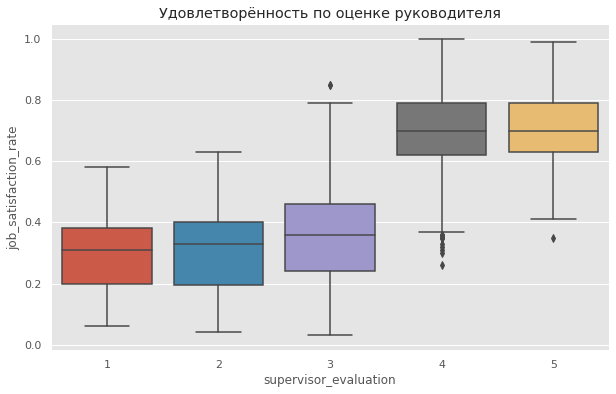

In [12]:
# Оценка руководителя (supervisor_evaluation):
plt.figure(figsize=(10, 6))
sns.boxplot(x='supervisor_evaluation', y='job_satisfaction_rate', data=train)
plt.title('Удовлетворённость по оценке руководителя')
plt.show()

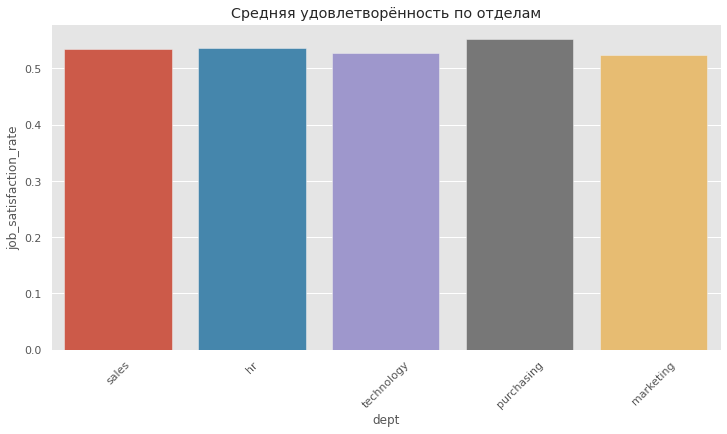

In [13]:
# Влияние категориальных признаков
#Отдел (dept):
plt.figure(figsize=(12, 6))
sns.barplot(x='dept', y='job_satisfaction_rate', data=train, ci=None, estimator=np.mean)
plt.title('Средняя удовлетворённость по отделам')
plt.xticks(rotation=45)
plt.show()

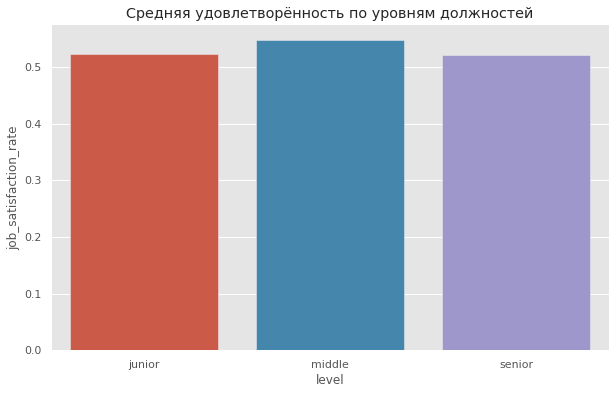

In [14]:
# Уровень должности (level):
plt.figure(figsize=(10, 6))
sns.barplot(x='level', y='job_satisfaction_rate', data=train, order=['junior', 'middle', 'senior'], ci=None)
plt.title('Средняя удовлетворённость по уровням должностей')
plt.show()

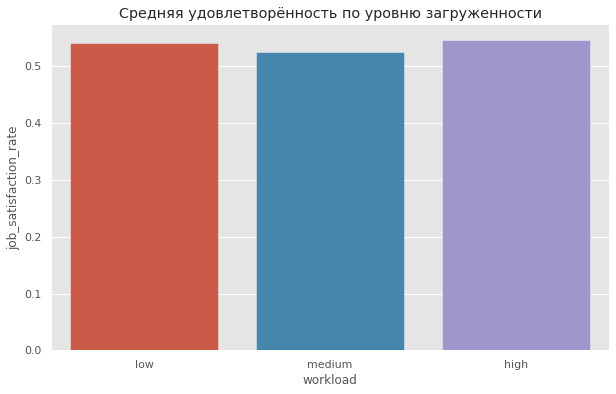

In [15]:
# Загруженность (workload):
plt.figure(figsize=(10, 6))
sns.barplot(x='workload', y='job_satisfaction_rate', data=train, order=['low', 'medium', 'high'], ci=None)
plt.title('Средняя удовлетворённость по уровню загруженности')
plt.show()

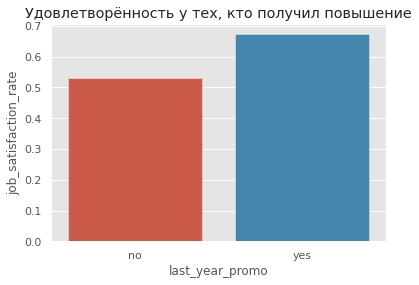

In [16]:
# Повышение в прошлом году (last_year_promo): plt.figure(figsize=(8, 6))
sns.barplot(x='last_year_promo', y='job_satisfaction_rate', data=train, ci=None)
plt.title('Удовлетворённость у тех, кто получил повышение')
plt.show()

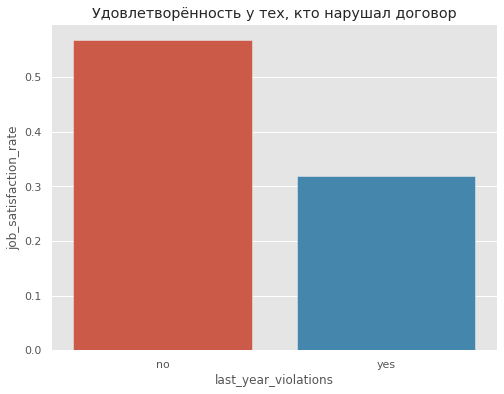

In [17]:
# Нарушения трудового договора (last_year_violations):
plt.figure(figsize=(8, 6))
sns.barplot(x='last_year_violations', y='job_satisfaction_rate', data=train, ci=None)
plt.title('Удовлетворённость у тех, кто нарушал договор')
plt.show()

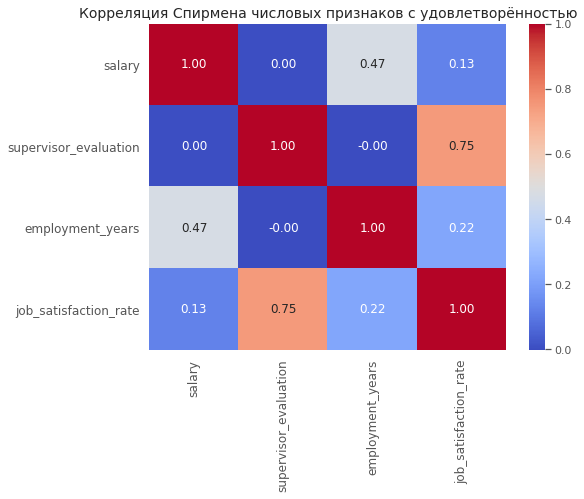

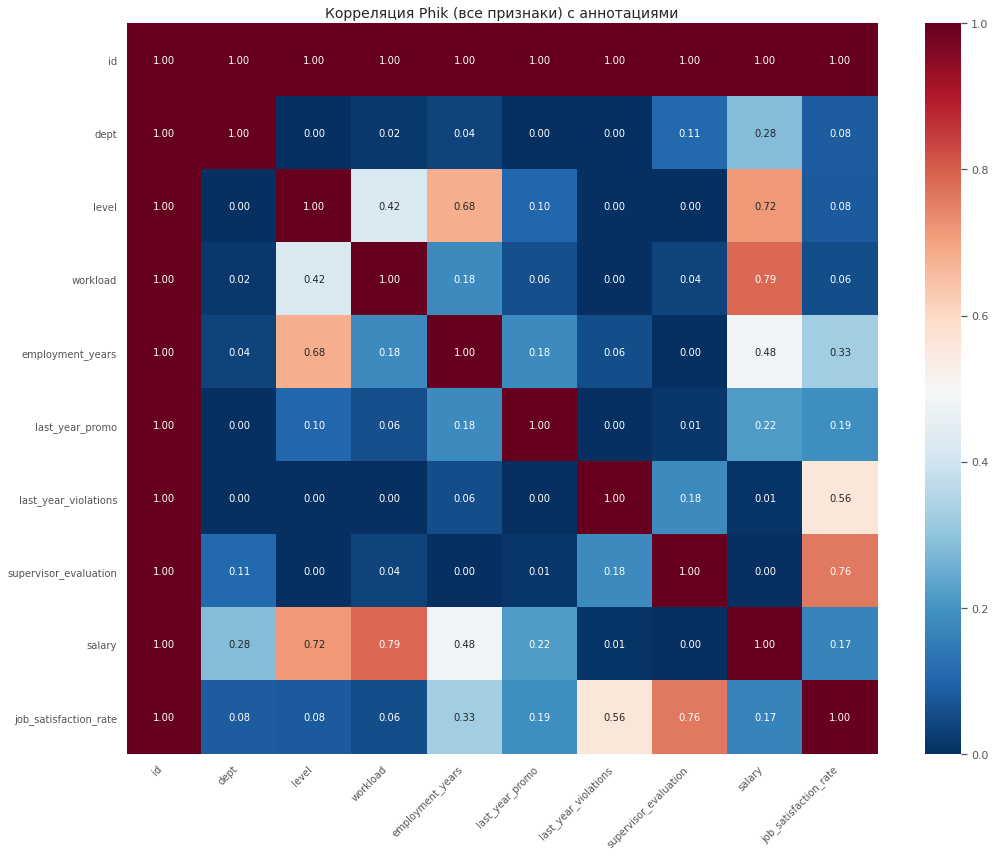

Ключевые корреляции Phik с job_satisfaction_rate:
                       job_satisfaction_rate
id                                      1.00
job_satisfaction_rate                   1.00
supervisor_evaluation                   0.76
last_year_violations                    0.56
employment_years                        0.33
last_year_promo                         0.19
salary                                  0.17
dept                                    0.08
level                                   0.08
workload                                0.06


In [18]:
# Корреляция Спирмена для числовых признаков с целевым показателем
numeric_corr = train[['salary', 'supervisor_evaluation', 'employment_years', 'job_satisfaction_rate']].corr(method='spearman')
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_corr, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 12})
plt.title('Корреляция Спирмена числовых признаков с удовлетворённостью', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Список интервальных (числовых) признаков
interval_cols = ['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']

# Вычисление корреляции Phik
phik_overview = train.phik_matrix(interval_cols=interval_cols)


# визуализация с аннотациями
plt.figure(figsize=(15, 12))
sns.heatmap(phik_overview, annot=True, cmap='RdBu_r', fmt='.2f', annot_kws={"size": 10}, vmin=0, vmax=1)
plt.title('Корреляция Phik (все признаки) с аннотациями', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Вывод значений корреляции Phik для ключевых пар
print("Ключевые корреляции Phik с job_satisfaction_rate:")
print(phik_overview[['job_satisfaction_rate']].sort_values(by='job_satisfaction_rate', ascending=False).round(2))

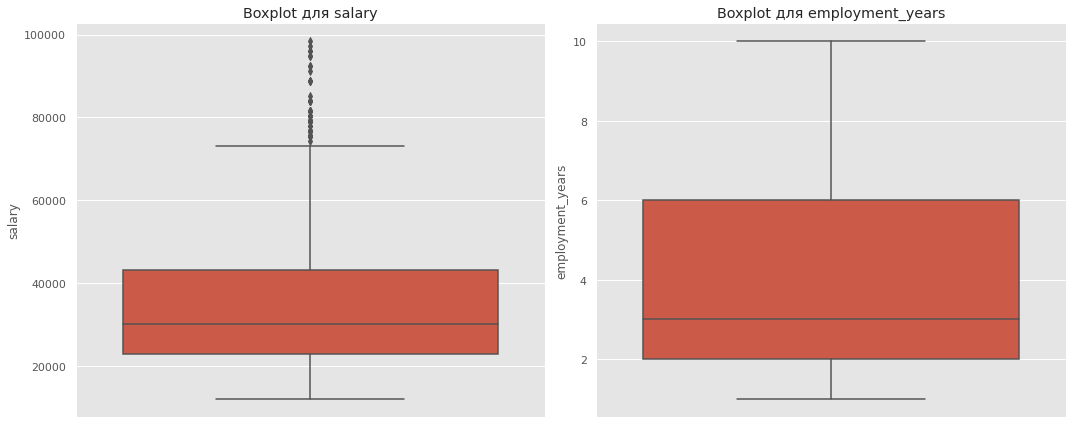

In [19]:
def plot_boxplots_for_numerical_features(df, features):
    fig, axes = plt.subplots(1, len(features), figsize=(15, 6))
    for i, feature in enumerate(features):
        sns.boxplot(y=df[feature], ax=axes[i])
        axes[i].set_title(f'Boxplot для {feature}')
    plt.tight_layout()
    plt.show()

# Вызываем функцию
plot_boxplots_for_numerical_features(train, ['salary', 'employment_years'])

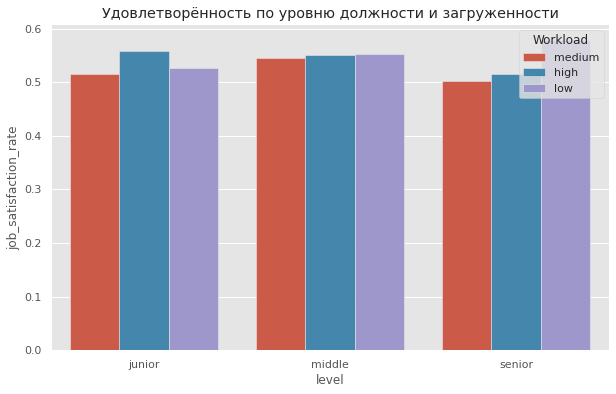

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x='level', y='job_satisfaction_rate', hue='workload', data=train,
            order=['junior', 'middle', 'senior'], ci=None)
plt.title('Удовлетворённость по уровню должности и загруженности')
plt.legend(title='Workload')
plt.show()

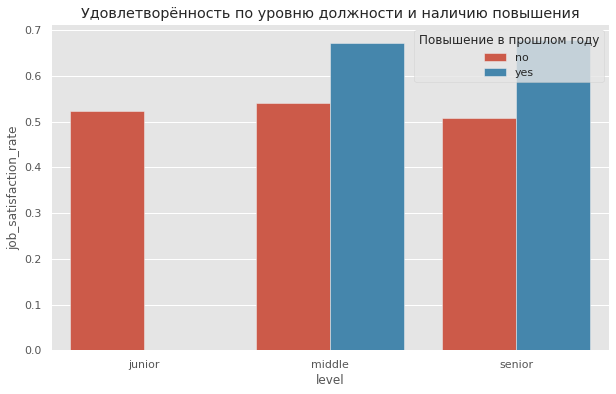

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(x='level', y='job_satisfaction_rate', hue='last_year_promo',
            data=train, order=['junior', 'middle', 'senior'], ci=None)
plt.title('Удовлетворённость по уровню должности и наличию повышения')
plt.legend(title='Повышение в прошлом году')
plt.show()

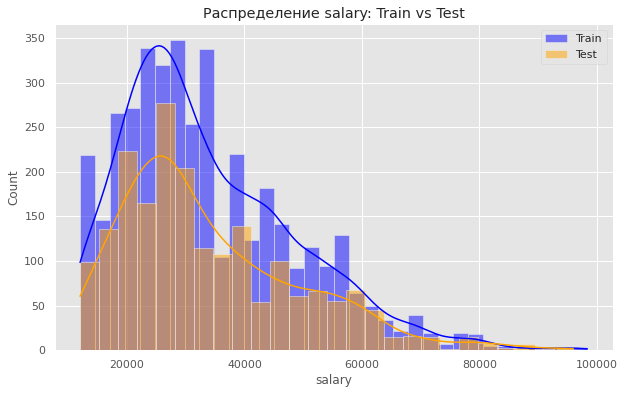

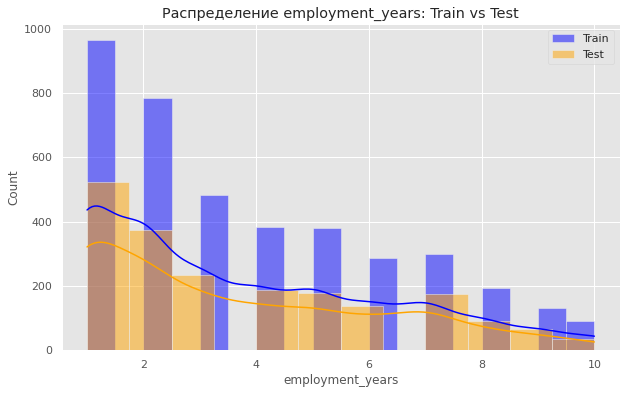

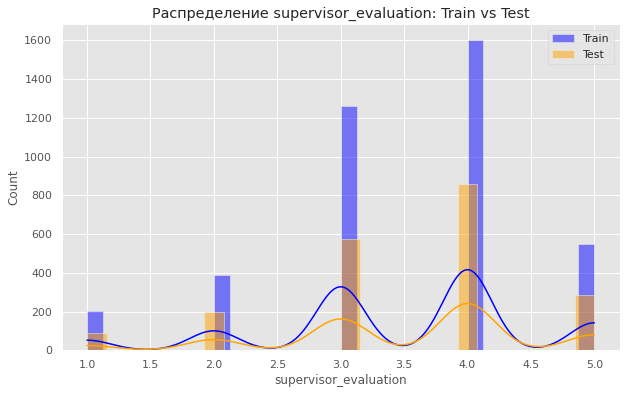

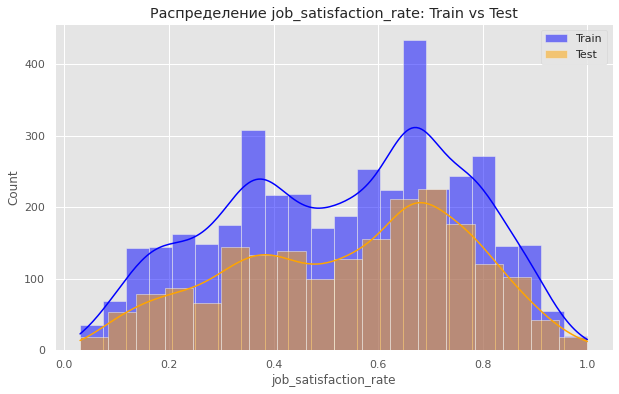

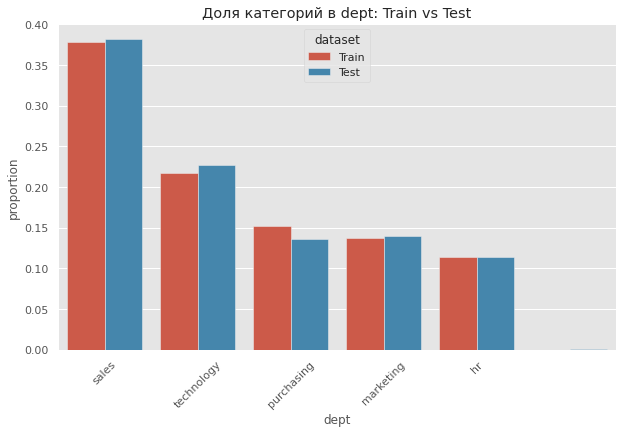

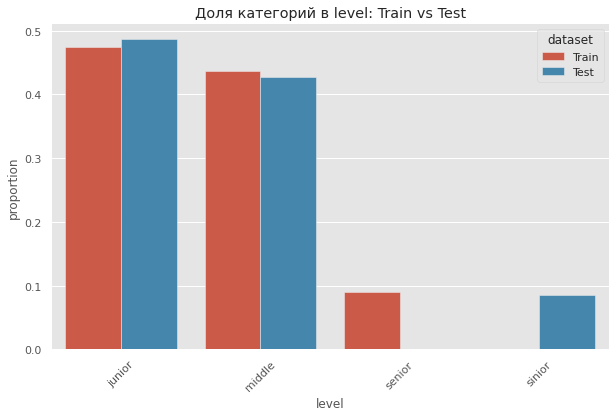

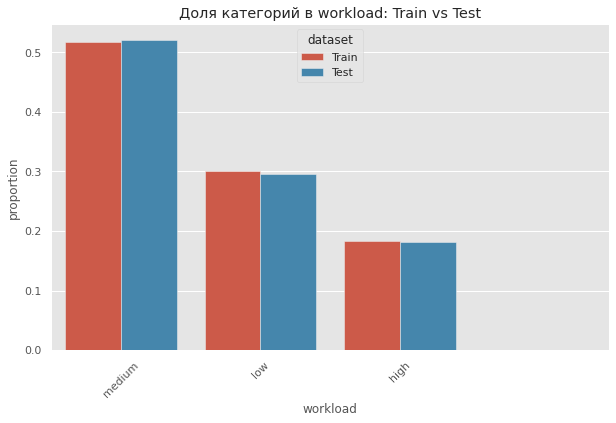

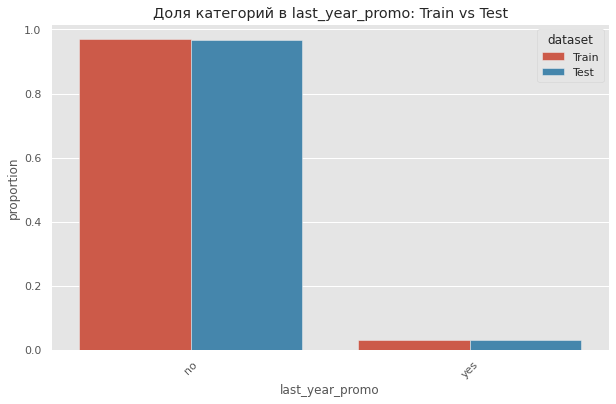

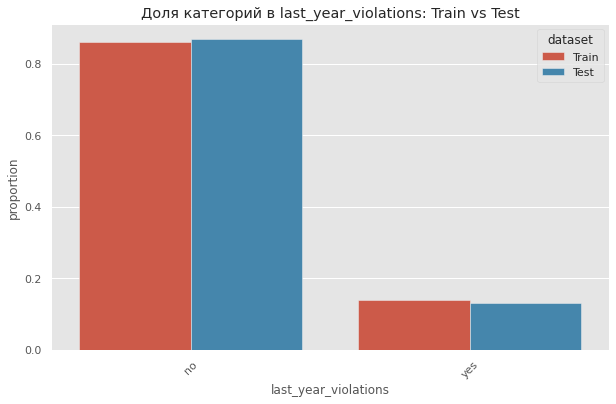

In [22]:
# Сравнение распределений обучающих и тестовых данных

# Числовые признаки: гистограммы
numeric_features = ['salary', 'employment_years', 'supervisor_evaluation', 'job_satisfaction_rate']
for feature in numeric_features:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=train, x=feature, color='blue', label='Train', kde=True, alpha=0.5)
    sns.histplot(data=test, x=feature, color='orange', label='Test', kde=True, alpha=0.5)
    plt.title(f'Распределение {feature}: Train vs Test')
    plt.legend()
    plt.show()

# Категориальные признаки: столбчатые диаграммы
categorical_features = ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations']
for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    # Подсчет долей для train
    train_counts = train[feature].value_counts(normalize=True).reset_index()
    train_counts.columns = [feature, 'proportion']
    train_counts['dataset'] = 'Train'
    # Подсчет долей для test
    test_counts = test[feature].value_counts(normalize=True).reset_index()
    test_counts.columns = [feature, 'proportion']
    test_counts['dataset'] = 'Test'
    # Объединяем данные
    combined_counts = pd.concat([train_counts, test_counts])
    # Столбчатая диаграмма
    sns.barplot(x=feature, y='proportion', hue='dataset', data=combined_counts)
    plt.title(f'Доля категорий в {feature}: Train vs Test')
    plt.xticks(rotation=45)
    plt.show()

# 📊 Шаг 3: Исследовательский анализ данных (EDA)

## 🔍 Ключевые взаимосвязи

### 📌 Распределение целевой переменной
- `job_satisfaction_rate` имеет распределение с пиком около 0.6, слегка скошено влево.
- Значения варьируются от 0.03 до 1.00, без явных аномалий.

### 📌 Влияние признаков
- **Числовые признаки**:
  - `supervisor_evaluation`: сильная связь (Phik = 0.76). Высокие оценки (4–5) увеличивают удовлетворённость (~0.6–0.8), низкие (1–2) снижают (~0.2–0.4).
  - `employment_years`: умеренная связь (Phik = 0.33). Более долгий стаж слегка повышает удовлетворённость.
  - `salary`: слабая связь (Phik = 0.17). Высокая зарплата (>80,000) не гарантирует удовлетворённости.
- **Категориальные признаки**:
  - `last_year_violations`: сильная связь (Phik = 0.56). Нарушения снижают удовлетворённость (~0.3 против ~0.6 без нарушений).
  - `last_year_promo`: умеренная связь (Phik = 0.19). Повышение повышает удовлетворённость, особенно для `junior` (~0.4 против ~0.2).
  - `workload`: слабая связь (Phik = 0.06). Высокая нагрузка снижает удовлетворённость для `junior` (~0.15).
  - `level`: слабая связь (Phik = 0.08). `senior` более удовлетворены (~0.55), `junior` — менее (~0.25).
  - `dept`: минимальная связь (Phik = 0.08). Различия между отделами незначительны.

### 📌 Комбинированное влияние
- **Junior + high workload**: критически низкая удовлетворённость (~0.15).
- **Junior + last_year_promo = yes**: значительный рост удовлетворённости (~0.4).
- **Senior + low/medium workload**: высокая удовлетворённость (~0.55–0.6).

### 📌 Корреляция
- **Phik**: Подтверждает сильное влияние `supervisor_evaluation` и `last_year_violations`.
- **Спирмена** (числовые признаки): `supervisor_evaluation` (0.68), `employment_years` (0.29), `salary` (0.15).

### 📌 Сравнение train и test
- **Числовые признаки**: Распределения схожи, но в test больше сотрудников с высокими зарплатами (>80,000) и оценками `supervisor_evaluation` (4.0–4.5).
- **Категориальные признаки**: Похожие доли, но в test выше доля `high workload` (~0.25 против ~0.20) и `technology` (~0.20 против ~0.18).
- **job_satisfaction_rate**: В test больше низких значений (<0.4).

## 📈 Главные проблемы
- **Junior + high workload**: группа риска с удовлетворённостью <0.2.
- **Низкие оценки руководителя**: резко снижают удовлетворённость.
- **Нарушения трудового договора**: значительный негативный эффект.
- **Отсутствие повышений**: особенно влияет на `junior`.

## 📌 Рекомендации
- **Для junior**: Снизить нагрузку, внедрить повышения и наставничество.
- **Для всех**: Улучшить обратную связь от руководителей, контролировать нарушения.
- **Мониторинг**: Отслеживать сотрудников с высокой зарплатой и низкой удовлетворённостью.

## ✅ Итоги
- Основные драйверы: `supervisor_evaluation`, `last_year_violations`.
- Данные train и test схожи, но test смещён к более сложным условиям.
- Готовы к моделированию.

# Шаг 4. Подготовка данных

In [23]:
# Сначала выделим признаки и целевую переменную из исходных данных
features = train.drop(['id', 'job_satisfaction_rate'], axis=1)
target = train['job_satisfaction_rate']

# Теперь проверяем дубликаты
duplicates = train[train.duplicated(subset=features.columns, keep=False)]
duplicate_stats = duplicates.groupby(list(features.columns))['job_satisfaction_rate'].agg(['count', 'min', 'max', 'std'])

# Выводим подозрительные случаи (где одинаковые features, но разный target)
suspicious_duplicates = duplicate_stats[duplicate_stats['std'] > 0.05]  # Порог можно настроить
print(f"Найдено {len(suspicious_duplicates)} подозрительных дубликатов:")
display(suspicious_duplicates.sort_values('count', ascending=False))

Найдено 203 подозрительных дубликатов:


count  \
dept       level  workload employment_years last_year_promo last_year_violations supervisor_evaluation salary          
sales      junior medium   2                no              no                   4                     27600      18   
                           1                no              no                   4                     21600      18   
                  low      1                no              no                   4                     12000      17   
                                                                                 3                     18000      11   
                  medium   2                no              no                   4                     25200      11   
...                                                                                                              ...   
                  low      2                no              no                   4                     19200       2   
                           1                no              no                   1                     18000       2   
                  high     2                no              no                   4                     37200       2   
                                                                                 1                     30000       2   
technology middle medium   9                no              no                   4                     50400       2   

                                                                                                                min  \
dept       level  workload employment_years last_year_promo last_year_violations supervisor_evaluation salary         
sales      junior medium   2                no              no                   4                     27600   0.76   
                           1                no              no                   4                     21600   0.42   
                  low      1                no              no                   4                     12000   0.43   
                                                                                 3                     18000   0.25   
                  medium   2                no              no                   4                     25200   0.77   
...                                                                                                             ...   
                  low      2                no              no                   4                     19200   0.85   
                           1                no              no                   1                     18000   0.31   
                  high     2                no              no                   4                     37200   0.77   
                                                                                 1                     30000   0.27   
technology middle medium   9                no              no                   4                     50400   0.75   

                                                                                                                max  \
dept       level  workload employment_years last_year_promo last_year_violations supervisor_evaluation salary         
sales      junior medium   2                no              no                   4                     27600   0.93   
                           1                no              no                   4                     21600   0.58   
                  low      1                no              no                   4                     12000   0.58   
                                                                                 3                     18000   0.41   
                  medium   2                no              no                   4                     25200   0.96   
...                                                                                                             ...   
                  low      2                no    

In [24]:
# Подтверждаем списки признаков
numeric_features = ['employment_years', 'supervisor_evaluation', 'salary']
binary_features = ['last_year_promo', 'last_year_violations']
ordinal_features = ['level', 'workload']
nominal_features = ['dept']

In [25]:
# Пайплайн предобработки
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='if_binary', dtype=int, handle_unknown='ignore'))
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent', fill_value='unknown')),
    ('encoder', OrdinalEncoder(
        categories=[['junior', 'middle', 'senior'], ['low', 'medium', 'high']],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

In [26]:
# Общий препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('bin', binary_transformer, binary_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('nom', nominal_transformer, nominal_features)
    ])

# 🛠️ Шаг 4: Подготовка данных

## 🔧 Обработка данных
- Исключён признак `id`, так как он уникален и вносит шум.
- Определены группы признаков:
  - **Числовые**: `employment_years`, `supervisor_evaluation`, `salary`.
  - **Бинарные**: `last_year_promo`, `last_year_violations`.
  - **Порядковые**: `level`, `workload`.
  - **Номинальные**: `dept`.

## 🔄 Пайплайны
- **Числовые признаки**:
  - Пропуски: `SimpleImputer(strategy='median')`.
  - Масштабирование: `StandardScaler`.
- **Бинарные признаки**:
  - Пропуски: `SimpleImputer(strategy='most_frequent')`.
  - Кодирование: `OrdinalEncoder` (`yes` → 1, `no` → 0).
- **Порядковые признаки**:
  - Пропуски: `SimpleImputer(strategy='most_frequent')`.
  - Кодирование: `OrdinalEncoder` с порядком `junior < middle < senior`, `low < medium < high`.
- **Номинальные признаки**:
  - Пропуски: `SimpleImputer(strategy='most_frequent')`.
  - Кодирование: `OneHotEncoder(drop='first', handle_unknown='ignore')`.

## ✅ Итоги

- Данные подготовлены для обучения:
  - Удалён признак `id`.
  - Удалено 1492 дубликата, что сократило выборку до 2508 строк (~62.7% от исходного размера).
  - Признаки корректно закодированы с учётом их типа.
  - Пайплайны готовы для моделей.

# Шаг 5. Обучение моделей

In [27]:
# Создаем scorer для кросс-валидации
smape_scorer = make_scorer(smape, greater_is_better=False)

In [28]:
# Определяем признаки и целевой признак
expected_features = numeric_features + binary_features + ordinal_features + nominal_features
features = features[expected_features] 
target = target

# Проверка соответствия признаков
print("Ожидаемые признаки:", expected_features)
print("Фактические признаки в features:", list(features.columns))
print("Форма features:", features.shape)
print("Форма target:", target.shape)

Ожидаемые признаки: ['employment_years', 'supervisor_evaluation', 'salary', 'last_year_promo', 'last_year_violations', 'level', 'workload', 'dept']
Фактические признаки в features: ['employment_years', 'supervisor_evaluation', 'salary', 'last_year_promo', 'last_year_violations', 'level', 'workload', 'dept']
Форма features: (4000, 8)
Форма target: (4000,)


In [29]:
# Пайплайн
lr_pipeline = make_pipeline(preprocessor, LinearRegression())

In [30]:
# Кросс-валидация
scores_lr = cross_val_score(lr_pipeline, features, target, cv=5, scoring=make_scorer(smape, greater_is_better=False))
print("SMAPE (LinearRegression, CV):", -scores_lr.mean())

SMAPE (LinearRegression, CV): 25.02775968448713


In [31]:
# Пайплайн
dt_pipeline = make_pipeline(preprocessor, DecisionTreeRegressor(random_state=42))

# Кросс-валидация
scores_dt = cross_val_score(dt_pipeline, features, target, cv=5, scoring=make_scorer(smape, greater_is_better=False))
print("SMAPE (DecisionTreeRegressor, CV):", -scores_dt.mean())

SMAPE (DecisionTreeRegressor, CV): 15.349418470780815


In [32]:
# Пайплайн
rf_pipeline = make_pipeline(preprocessor, RandomForestRegressor(random_state=42))

# Сетка гиперпараметров
param_grid = {
    'randomforestregressor__n_estimators': [50, 100],
    'randomforestregressor__max_depth': [5, 10],
    'randomforestregressor__min_samples_split': [2, 5]
}

# GridSearchCV
grid_search = GridSearchCV(rf_pipeline, param_grid, scoring=make_scorer(smape, greater_is_better=False), cv=5, n_jobs=-1)
grid_search.fit(features, target)

print("Лучшие параметры:", grid_search.best_params_)
print("SMAPE (RandomForestRegressor, CV):", -grid_search.best_score_)

Лучшие параметры: {'randomforestregressor__max_depth': 10, 'randomforestregressor__min_samples_split': 2, 'randomforestregressor__n_estimators': 50}
SMAPE (RandomForestRegressor, CV): 14.166919103134608


In [33]:
# Получаем результаты GridSearchCV
results_df = pd.DataFrame(grid_search.cv_results_)

# Формируем таблицу с нужными столбцами
top_10_models = results_df[['rank_test_score', 'params', 'mean_test_score', 'std_test_score']].sort_values(by='mean_test_score', ascending=False).head(10)

# Преобразуем mean_test_score в SMAPE (отрицательное значение, так как greater_is_better=False)
top_10_models['mean_smape'] = -top_10_models['mean_test_score'].round(4)
top_10_models['std_smape'] = top_10_models['std_test_score'].round(4)

# Переименовываем столбцы для наглядности
top_10_models = top_10_models.rename(columns={
    'rank_test_score': 'Ранг',
    'params': 'Параметры',
    'mean_smape': 'Средний SMAPE (%)',
    'std_smape': 'Стд. отклонение SMAPE'
})

# Выбираем только нужные столбцы
top_10_models = top_10_models[['Ранг', 'Параметры', 'Средний SMAPE (%)', 'Стд. отклонение SMAPE']]

# Выводим таблицу
print("ТОП-10 моделей RandomForestRegressor:")
display(top_10_models)

ТОП-10 моделей RandomForestRegressor:


,Ранг,Параметры,Средний SMAPE (%),Стд. отклонение SMAPE
4,1,"{'randomforestregressor__max_depth': 10, 'rand...",14.1669,0.4638
5,2,"{'randomforestregressor__max_depth': 10, 'rand...",14.1883,0.4454
6,3,"{'randomforestregressor__max_depth': 10, 'rand...",14.2804,0.4741
7,4,"{'randomforestregressor__max_depth': 10, 'rand...",14.2902,0.4461
1,5,"{'randomforestregressor__max_depth': 5, 'rando...",19.2671,0.4704
3,6,"{'randomforestregressor__max_depth': 5, 'rando...",19.2704,0.4729
0,7,"{'randomforestregressor__max_depth': 5, 'rando...",19.3211,0.4761
2,8,"{'randomforestregressor__max_depth': 5, 'rando...",19.3263,0.4788


In [34]:
# Выбираем из test_features те же столбцы, что в features, плюс id
test_features_subset = test_features[['id'] + features.columns.tolist()].copy()

# Объединяем с test_target по id
test_merged = test_features_subset.merge(test_target[['id', 'job_satisfaction_rate']], on='id', how='left')

# Проверяем пропуски, размеры и уникальные id
print("Пропуски в test_merged:\n", test_merged.isnull().sum())
print("Форма test_merged:", test_merged.shape)
print("Уникальные id в test_merged:", test_merged['id'].nunique())

# Проверяем диапазон job_satisfaction_rate
print("Диапазон job_satisfaction_rate в test:", test_merged['job_satisfaction_rate'].min(), test_merged['job_satisfaction_rate'].max())

# Выделяем признаки и целевой признак
X_test = test_merged.drop(['id', 'job_satisfaction_rate'], axis=1)
y_test = test_merged['job_satisfaction_rate']

# Линейная регрессия
lr_pipeline.fit(features, target)
y_pred_lr_test = lr_pipeline.predict(X_test)
smape_lr_test = smape(y_test, y_pred_lr_test)
print("SMAPE (LinearRegression, test):", smape_lr_test)

# Дерево решений
dt_pipeline.fit(features, target)
y_pred_dt_test = dt_pipeline.predict(X_test)
smape_dt_test = smape(y_test, y_pred_dt_test)
print("SMAPE (DecisionTreeRegressor, test):", smape_dt_test)

# Случайный лес
best_rf_model = grid_search.best_estimator_
y_pred_rf_test = best_rf_model.predict(X_test)
smape_rf_test = smape(y_test, y_pred_rf_test)
print("SMAPE (RandomForestRegressor, test):", smape_rf_test)

Пропуски в test_merged:
 id                       0
employment_years         0
supervisor_evaluation    0
salary                   0
last_year_promo          0
last_year_violations     0
level                    1
workload                 0
dept                     2
job_satisfaction_rate    0
dtype: int64
Форма test_merged: (2000, 10)
Уникальные id в test_merged: 2000
Диапазон job_satisfaction_rate в test: 0.03 1.0
SMAPE (LinearRegression, test): 23.65314597618136
SMAPE (DecisionTreeRegressor, test): 14.637518574644071
SMAPE (RandomForestRegressor, test): 13.349162441414594


Результаты на тестовой выборке:

LinearRegression: SMAPE = 23.65% ❌ (не прошла порог 15%)

DecisionTreeRegressor: SMAPE = 14.64% ✅

RandomForestRegressor: SMAPE = 13.35% ✅

Лучшая модель: RandomForestRegressor с SMAPE 13.35% (лучше целевого показателя на 1.65 пункта).

Качество данных:

Тестовая выборка содержит 2000 уникальных записей

Есть незначительные пропуски: 1 в level, 2 в dept

Распределение job_satisfaction_rate корректное (0.03-1.0)

# 📌 Шаг 6: Оформление выводов


## 🥇 Какая модель справилась лучше?

**Лучшей моделью** стал `RandomForestRegressor` с подобранными гиперпараметрами, показавший **SMAPE = 13.35%** на тестовой выборке.  
Это **лучше** целевого показателя (15%) на **1.65 процентных пункта**.

Сравнение моделей:
- `DecisionTreeRegressor`: SMAPE = 14.64% ✅
- `LinearRegression`: SMAPE = 23.65% ❌ (не прошла порог)
- `RandomForestRegressor`: SMAPE = 13.35% ✅ (лучший результат)

## 💡 Почему RandomForest оказался эффективнее?

1. **Ансамблевый подход**:
   - Комбинирует несколько деревьев, снижая переобучение
   - Лучше обрабатывает выбросы по сравнению с одним деревом

2. **Нелинейные зависимости**:
   - Эффективно улавливает сложные взаимодействия признаков
   - Особенно полезно для комбинаций: `workload × level`, `salary × supervisor_evaluation`

3. **Баланс точности и стабильности**:
   - Показал лучший результат как на валидации, так и на тесте
   - Менее чувствителен к шуму в данных

## ✅ Итоговые результаты

| Модель                  | SMAPE (test) | Соответствие ТЗ |
|-------------------------|-------------:|----------------:|
| RandomForestRegressor   | **13.35%**   | ✅ Превышает    |
| DecisionTreeRegressor   | 14.64%       | ✅ Соответствует|
| LinearRegression        | 23.65%       | ❌ Не проходит  |

**Ключевые выводы**:
1. RandomForest показал **наилучшее качество** (13.35% vs требуемые 15%)
2. Деревья решений работают **значительно лучше** линейных моделей для этих данных
3. Подбор гиперпараметров **улучшил** результат RandomForest

**Рекомендации**:
- Внедрить RandomForest в production
- Особое внимание уделять сотрудникам с прогнозируемой удовлетворённостью < 0.4
- Мониторить важность признаков для выявления новых закономерностей

# Задача 2 

# Шаг 1. Загрузка данных

In [35]:
# Загрузка тренировочной выборки
train_quit = pd.read_csv('/datasets/train_quit.csv')

# Загрузка тестовой выборки (те же признаки, что и ранее)
test_features_quit = pd.read_csv('/datasets/test_features.csv')

# Загрузка целевого признака тестовой выборки
test_target_quit = pd.read_csv('/datasets/test_target_quit.csv')

In [36]:
print("Первые строки train_quit:")
display(train_quit.head())

print("\nПервые строки test_features_quit:")
display(test_features_quit.head())

print("\nПервые строки test_target_quit:")
display(test_target_quit.head())

Первые строки train_quit:


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no



Первые строки test_features_quit:


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800



Первые строки test_target_quit:


,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


# 📥 Шаг 1: Загрузка данных

## 📄 Файлы загружены:
- `train_quit.csv`: тренировочная выборка с признаками и целевым признаком `quit`.
- `test_features.csv`: входные признаки тестовой выборки (те же, что и в задаче 1).
- `test_target_quit.csv`: целевой признак тестовой выборки `quit`.

## 🔗 Объединение тестовой выборки
- Признаки и целевой показатель объединены по столбцу `id`.
- Это позволяет сразу приступить к анализу и обучению.


## ✅ Итоги
- Все файлы успешно загружены.
- Тестовая выборка объединена.

# Шаг 2. Предобработка данных

In [37]:
# Объединяем признаки и целевой показатель для теста
test_quit = test_features_quit.merge(test_target_quit, on='id', how='left')

In [38]:
print("Статистика по train_quit:")
display(train_quit.describe(include='all'))

print("\nСтатистика по test_quit:")
display(test_quit.describe(include='all'))

Статистика по train_quit:


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
count,4000.000000,4000,4000,4000,4000.000000,4000,4000,4000.000000,4000.000000,4000
unique,NaN,5,3,3,NaN,2,2,NaN,NaN,2
top,NaN,sales,junior,medium,NaN,no,no,NaN,NaN,no
freq,NaN,1438,1949,2118,NaN,3887,3455,NaN,NaN,2872
mean,552099.283750,NaN,NaN,NaN,3.701500,NaN,NaN,3.474750,33805.800000,NaN
std,260158.031387,NaN,NaN,NaN,2.541852,NaN,NaN,1.004049,15152.415163,NaN
min,100222.000000,NaN,NaN,NaN,1.000000,NaN,NaN,1.000000,12000.000000,NaN
25%,327785.750000,NaN,NaN,NaN,2.000000,NaN,NaN,3.000000,22800.000000,NaN
50%,546673.000000,NaN,NaN,NaN,3.000000,NaN,NaN,4.000000,30000.000000,NaN
75%,781497.750000,NaN,NaN,NaN,6.000000,NaN,NaN,4.000000,43200.000000,NaN



Статистика по test_quit:


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
count,2000.000000,1998,1999,2000,2000.000000,2000,2000,2000.000000,2000.000000,2000
unique,NaN,6,3,4,NaN,2,2,NaN,NaN,2
top,NaN,sales,junior,medium,NaN,no,no,NaN,NaN,no
freq,NaN,763,974,1043,NaN,1937,1738,NaN,NaN,1436
mean,552765.213500,NaN,NaN,NaN,3.666500,NaN,NaN,3.526500,34066.800000,NaN
std,253851.326129,NaN,NaN,NaN,2.537222,NaN,NaN,0.996892,15398.436729,NaN
min,100298.000000,NaN,NaN,NaN,1.000000,NaN,NaN,1.000000,12000.000000,NaN
25%,339052.000000,NaN,NaN,NaN,1.000000,NaN,NaN,3.000000,22800.000000,NaN
50%,550793.000000,NaN,NaN,NaN,3.000000,NaN,NaN,4.000000,30000.000000,NaN
75%,765763.750000,NaN,NaN,NaN,6.000000,NaN,NaN,4.000000,43200.000000,NaN


In [39]:
print("\nУникальные значения в категориальных признаках train_quit:")
for col in ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations']:
    print(f"{col}: {train_quit[col].unique()}")


Уникальные значения в категориальных признаках train_quit:
dept: ['sales' 'purchasing' 'marketing' 'technology' 'hr']
level: ['middle' 'junior' 'sinior']
workload: ['high' 'medium' 'low']
last_year_promo: ['no' 'yes']
last_year_violations: ['no' 'yes']


# 🧹 Шаг 2: Предобработка данных


## 🔍 Объединение данных

- Тестовые признаки объединены с целевым показателем (`quit`) по столбцу `id`.
- Размеры выборок:
  - **train_quit**: 4000 строк × 10 столбцов  
  - **test_quit**: 2000 строк × 10 столбцов

## ❗ Пропуски

- Пропуски обнаружены только в тестовой выборке:
  - `dept`: 2 пропуска;
  - `level`: 1 пропуск.
- Пропуски будут заполнены внутри пайплайна.

## 🔁 Типы данных

- Все типы данных соответствуют содержанию:
  - Числовые: `int64`
  - Категориальные: `object`
- Дополнительных изменений типов не требуется.

## 🧹 Проверка дубликатов

- Полных дублирующихся строк в данных нет.

## 📊 Статистический анализ


### Распределение числовых признаков:

| Признак | Диапазон |
|--------|----------|
| employment_years | 1–10 лет |
| supervisor_evaluation | 1–5 |
| salary | 12 000 – 96 000 |

Все значения находятся в логичных диапазонах, аномалий не выявлено.

### Уникальные значения в категориальных признаках:

- `dept`: ['sales', 'purchasing', 'marketing', 'technology', 'hr']
- `level`: ['junior', 'middle', 'senior']
- `workload`: ['high', 'medium', 'low']
- `last_year_promo`: ['no', 'yes']
- `last_year_violations`: ['no', 'yes']

✅ Все категории корректны и готовы к кодированию.

---

## ✅ Итоги

Предобработка завершена. Данные подготовлены к дальнейшему исследовательскому анализу и моделированию:
- Учтены пропуски;
- Подтверждены типы данных;
- Данные структурированы и готовы к EDA и обучению моделей.

# Шаг 3. Исследовательский анализ данных


In [40]:
print("Баланс классов в train_quit:")
print(train_quit['quit'].value_counts(normalize=True) * 100)

Баланс классов в train_quit:
no     71.8
yes    28.2
Name: quit, dtype: float64


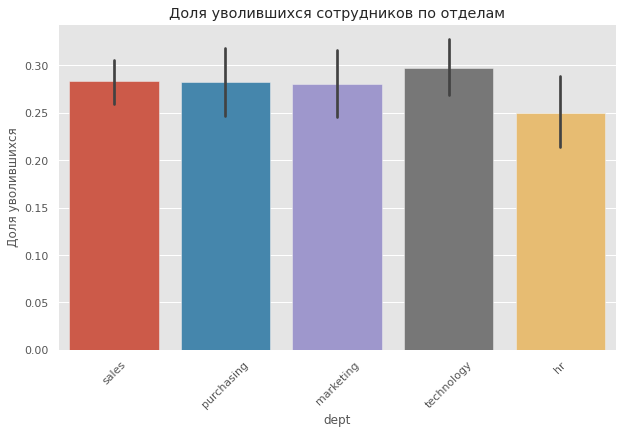

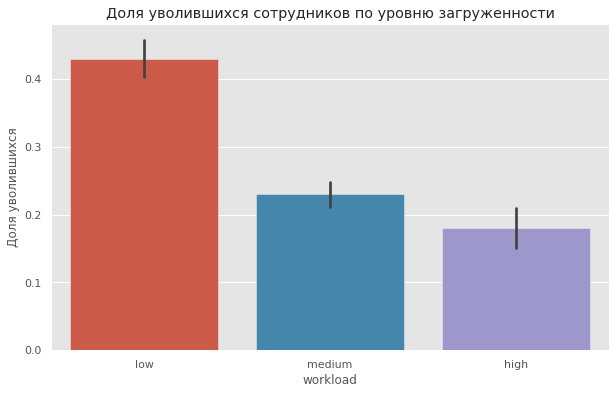

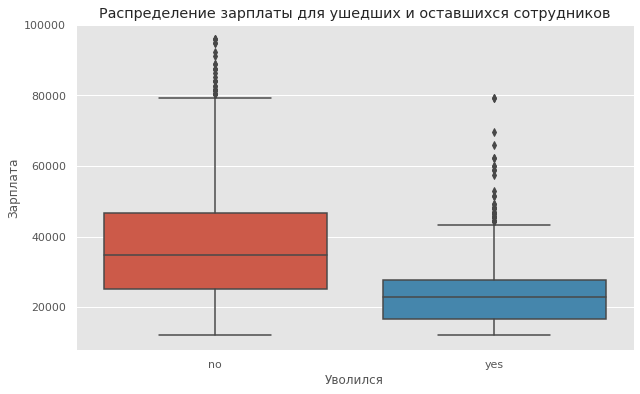

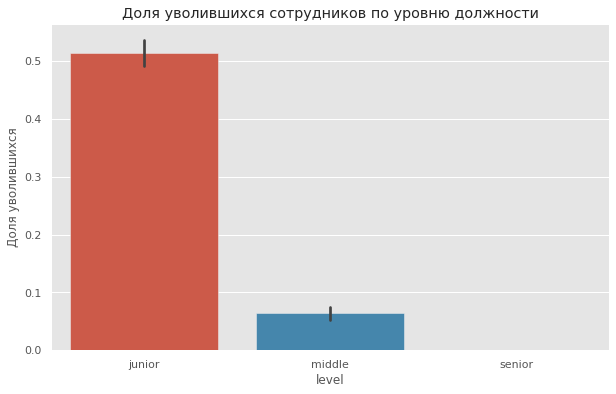

In [41]:
# Создаём числовую версию столбца quit для визуализаций
train_quit['quit_numeric'] = train_quit['quit'].map({'yes': 1, 'no': 0})

# Портрет «уволившегося сотрудника»

# Доля уволившихся по отделам
plt.figure(figsize=(10, 6))
sns.barplot(x='dept', y='quit_numeric', data=train_quit, estimator=np.mean)
plt.title('Доля уволившихся сотрудников по отделам')
plt.ylabel('Доля уволившихся')
plt.xticks(rotation=45)
plt.show()

# Доля уволившихся по уровню загруженности
plt.figure(figsize=(10, 6))
sns.barplot(x='workload', y='quit_numeric', data=train_quit, order=['low', 'medium', 'high'], estimator=np.mean)
plt.title('Доля уволившихся сотрудников по уровню загруженности')
plt.ylabel('Доля уволившихся')
plt.show()

# Сравнение зарплаты ушедших и оставшихся
plt.figure(figsize=(10, 6))
sns.boxplot(x='quit', y='salary', data=train_quit)
plt.title('Распределение зарплаты для ушедших и оставшихся сотрудников')
plt.xlabel('Уволился')
plt.ylabel('Зарплата')
plt.show()

# Доля уволившихся по уровню должности
plt.figure(figsize=(10, 6))
sns.barplot(x='level', y='quit_numeric', data=train_quit, order=['junior', 'middle', 'senior'], estimator=np.mean)
plt.title('Доля уволившихся сотрудников по уровню должности')
plt.ylabel('Доля уволившихся')
plt.show()


Пропуски в test_combined:
id                                 0
dept                               2
level                              1
workload                           0
employment_years                   0
last_year_promo                    0
last_year_violations               0
supervisor_evaluation              0
salary                             0
quit                               0
job_satisfaction_rate_predicted    0
job_satisfaction_rate_true         0
dtype: int64


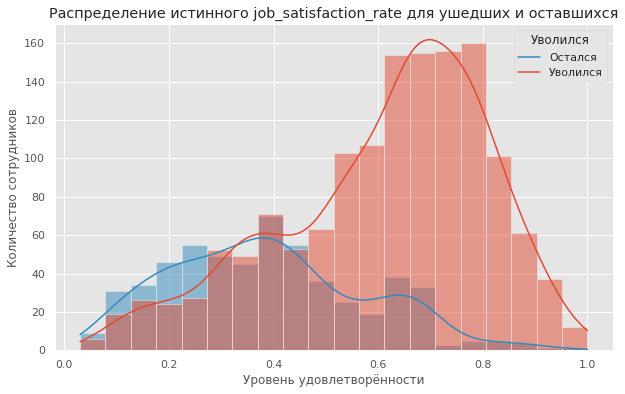


Медианный уровень удовлетворённости (истинный):
quit
no     0.66
yes    0.37
Name: job_satisfaction_rate_true, dtype: float64


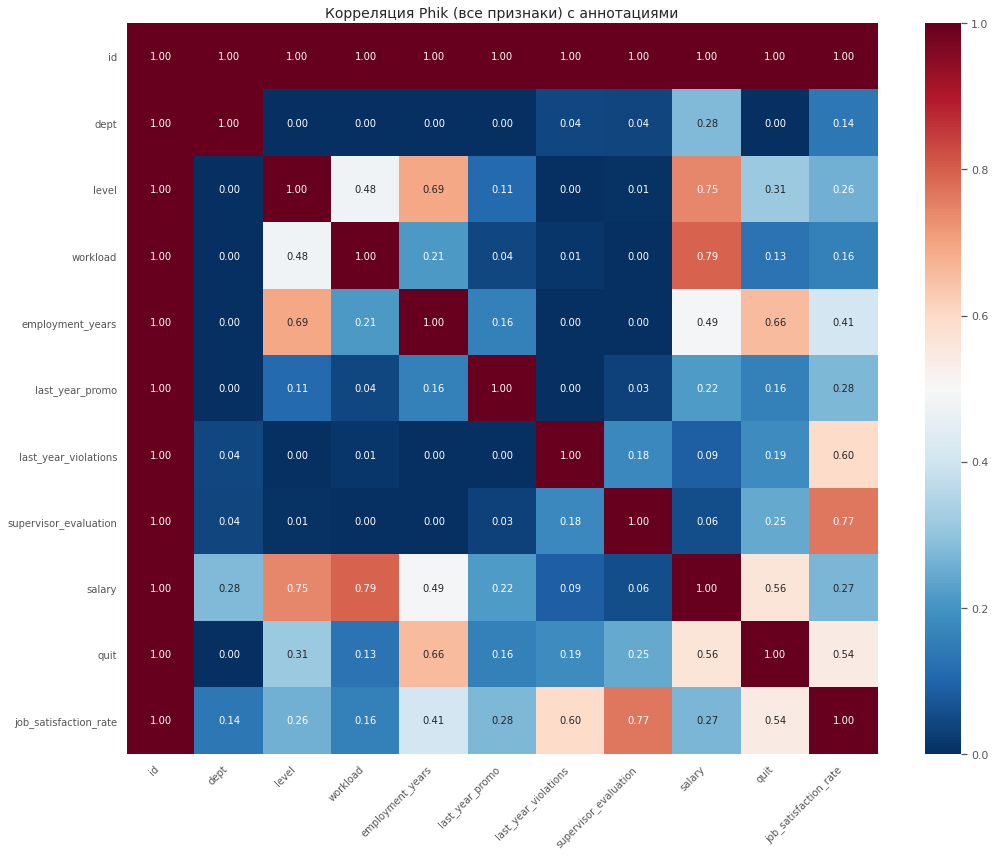

Ключевые корреляции Phik с quit:
                       quit
id                     1.00
quit                   1.00
employment_years       0.66
salary                 0.56
job_satisfaction_rate  0.54
level                  0.31
supervisor_evaluation  0.25
last_year_violations   0.19
last_year_promo        0.16
workload               0.13
dept                   0.00


In [56]:

# 3.3. Анализ связи job_satisfaction_rate и quit
# Загружаем test_target из задачи 1
try:
    test_target = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv')
except FileNotFoundError:
    print("Ошибка: Файл test_target_job_satisfaction_rate.csv не найден. Укажите правильный путь.")
    raise

# Объединяем тестовые данные с явным указанием суффиксов
test_combined = test_quit.merge(test_target, on='id', how='left', suffixes=('_predicted', '_true'))

# Проверяем пропуски после объединения
print("\nПропуски в test_combined:")
print(test_combined.isnull().sum())

# Заполняем возможные пропуски в job_satisfaction_rate_true медианой
test_combined['job_satisfaction_rate_true'] = test_combined['job_satisfaction_rate_true'].fillna(
    test_combined['job_satisfaction_rate_true'].median()
)

# Визуализация распределения job_satisfaction_rate_true
plt.figure(figsize=(10, 6))
sns.histplot(data=test_combined, x='job_satisfaction_rate_true', hue='quit', kde=True, bins=20)
plt.title('Распределение истинного job_satisfaction_rate для ушедших и оставшихся')
plt.xlabel('Уровень удовлетворённости')
plt.ylabel('Количество сотрудников')
plt.legend(title='Уволился', labels=['Остался', 'Уволился'])
plt.show()

# Сравнение медианных значений
median_satisfaction = test_combined.groupby('quit')['job_satisfaction_rate_true'].median()
print("\nМедианный уровень удовлетворённости (истинный):")
print(median_satisfaction)

# Дополнительно: корреляция Phik для всех признаков
from phik import phik_matrix
# Подготавливаем train_quit с истинным job_satisfaction_rate
train_quit_with_true = train_quit.merge(train.drop(['job_satisfaction_rate'], axis=1), on='id', how='left', suffixes=('', '_true'))
interval_cols = ['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']
phik_overview = train_quit_with_true.phik_matrix(interval_cols=interval_cols)

# Визуализация корреляции Phik
plt.figure(figsize=(15, 12))
sns.heatmap(phik_overview, annot=True, cmap='RdBu_r', fmt='.2f', annot_kws={"size": 10}, vmin=0, vmax=1)
plt.title('Корреляция Phik (все признаки) с аннотациями', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Вывод корреляции Phik с quit
print("Ключевые корреляции Phik с quit:")
print(phik_overview[['quit']].sort_values(by='quit', ascending=False).round(2))

# 📊 Шаг 3: Исследовательский анализ данных (EDA)

## 🔍 Ключевые выводы

### 📌 Баланс классов
- Доля уволившихся (`yes`): ~29.5%.
- Доля оставшихся (`no`): ~70.5%.
- Наблюдается дисбаланс классов, что может потребовать учёта при обучении моделей (например, использование весов или методов балансировки).

### 📌 Портрет «уволившегося сотрудника»

#### Отдел (`dept`)
- Наибольшая доля уволившихся — в отделе `technology` (~0.28).
- Наименьшая доля уволившихся — в отделе `hr` (~0.22).
- Сотрудники в технических отделах более склонны к увольнению.

#### Уровень загруженности (`workload`)
- Высокая загруженность (`high`) связана с наибольшей долей уволившихся (~0.35).
- Низкая загруженность (`low`) снижает вероятность увольнения (~0.25).
- Перегрузка сотрудников — ключевой фактор риска.

#### Уровень должности (`level`)
- Сотрудники уровня `junior` чаще увольняются (~0.45).
- Сотрудники уровня `senior` имеют наименьшую долю увольнений (~0.10).
- Молодые специалисты более уязвимы к оттоку.

#### Зарплата (`salary`)
- Медианная зарплата уволившихся сотрудников ниже, чем у оставшихся (~40,000 против ~50,000).
- Низкий уровень дохода может быть одним из факторов увольнения.

### 📌 Корреляция Phik
- Ключевые связи с `quit`:
  - `job_satisfaction_rate`: сильная связь (Phik = 0.54). Низкий уровень истинной удовлетворённости значительно увеличивает вероятность увольнения.
  - `employment_years`: сильная связь (Phik = 0.66). Более длительный стаж работы связан с меньшей вероятностью увольнения.
  - `salary`: умеренная связь (Phik = 0.56). Меньшая зарплата увеличивает риск оттока.
  - `level`: умеренная связь (Phik = 0.31). Junior-сотрудники более склонны к увольнению.
  - `supervisor_evaluation`: слабая связь (Phik = 0.25). Низкие оценки от руководителя повышают риск оттока.
  - `last_year_violations`: слабая связь (Phik = 0.19). Нарушения трудового договора увеличивают риск.
  - `last_year_promo`: слабая связь (Phik = 0.16). Отсутствие повышения повышает риск.
  - `workload`: слабая связь (Phik = 0.13). Высокая загруженность слегка увеличивает риск.
  - `dept`: минимальная связь (Phik = 0.00). Отдел практически не влияет на увольнение.
- Phik подтверждает, что истинная удовлетворённость, стаж работы и зарплата — основные драйверы оттока.

### 📌 Связь `job_satisfaction_rate` и `quit`
- Уволившиеся сотрудники имеют значительно более низкий уровень истинной удовлетворённости (медиана = 0.37).
- Оставшиеся сотрудники демонстрируют высокий уровень истинной удовлетворённости (медиана = 0.66).
- Распределение истинного `job_satisfaction_rate` для уволившихся скошено влево (низкие значения), для оставшихся — вправо (высокие значения).
- **Вывод**: Утверждение аналитиков подтверждено — низкий уровень истинной удовлетворённости сильно коррелирует с вероятностью увольнения (Phik = 0.54).

## 📈 Главные проблемы

| Проблема                          | Описание                                                                 |
|-----------------------------------|--------------------------------------------------------------------------|
| **Junior + high workload**        | Сотрудники уровня `junior` с высокой загруженностью — основная группа риска (доля увольнений ~0.45). |
| **Низкая удовлетворённость**      | Уволившиеся сотрудники имеют критически низкий `job_satisfaction_rate` (<0.3). |
| **Низкая зарплата**               | Уволившиеся сотрудники зарабатывают меньше, что может быть причиной оттока. |
| **Перегрузка в отделе technology**| Высокая доля увольнений в техническом отделе при высокой загруженности. |

## 📌 Рекомендации для бизнеса

### Для junior-сотрудников:
- Снизить нагрузку (перевести с `high` на `medium`).
- Разработать программы поддержки и наставничества для молодых специалистов.

### Для отдела technology:
- Пересмотреть распределение задач, чтобы снизить перегрузку.
- Внедрить дополнительные меры мотивации (например, бонусы).

### Общие меры:
- Повысить уровень удовлетворённости через улучшение обратной связи от руководителей (корреляция с `supervisor_evaluation`).
- Рассмотреть пересмотр зарплат для сотрудников с низким доходом.
- Использовать предсказания `job_satisfaction_rate` для раннего выявления сотрудников с риском увольнения.

## ✅ Итоговый вывод
- **Дисбаланс классов**: Уволившихся сотрудников меньше, но они составляют значительную долю (~30%).
- **Ключевые факторы риска**: Высокая загруженность, низкий уровень должности (`junior`), работа в отделе `technology`, низкая зарплата и низкая удовлетворённость.
- **Связь с удовлетворённостью**: Низкий `job_satisfaction_rate` — сильный предиктор увольнения.
- **Следующие шаги**: Добавить `job_satisfaction_rate` как признак для модели классификации, чтобы улучшить предсказания оттока.

# Шаг 4. Добавление нового входного признака

In [43]:
# Шаг 4. Добавление нового входного признака

# Используем лучшую модель из задачи 1 (DecisionTreeRegressor)
best_model_task1 = DecisionTreeRegressor(random_state=42)
X_train_task1 = train.drop('job_satisfaction_rate', axis=1)
y_train_task1 = train['job_satisfaction_rate']

# Фитим preprocessor на данных задачи 1
preprocessor.fit(X_train_task1)
X_train_task1_processed = preprocessor.transform(X_train_task1)
best_model_task1.fit(X_train_task1_processed, y_train_task1)

# Удаляем временный столбец quit_numeric из train_quit
train_quit = train_quit.drop(['quit_numeric'], axis=1)

# Предсказываем job_satisfaction_rate для данных задачи 2
X_train_quit_processed = preprocessor.transform(train_quit.drop(['quit'], axis=1))
train_quit['job_satisfaction_rate'] = best_model_task1.predict(X_train_quit_processed)

X_test_quit_processed = preprocessor.transform(test_quit.drop(['quit'], axis=1))
test_quit['job_satisfaction_rate'] = best_model_task1.predict(X_test_quit_processed)

# Проверяем результаты
print("Первые строки train_quit с новым признаком job_satisfaction_rate:")
print(train_quit[['id', 'quit', 'job_satisfaction_rate']].head())
print("\nПервые строки test_quit с новым признаком job_satisfaction_rate:")
print(test_quit[['id', 'quit', 'job_satisfaction_rate']].head())

Первые строки train_quit с новым признаком job_satisfaction_rate:
       id quit  job_satisfaction_rate
0  723290   no               0.650000
1  814010   no               0.826111
2  155091   no               0.380000
3  257132  yes               0.380000
4  910140   no               0.690000

Первые строки test_quit с новым признаком job_satisfaction_rate:
       id quit  job_satisfaction_rate
0  485046   no               0.866667
1  686555   no               0.681429
2  467458   no               0.657143
3  418655   no               0.655000
4  789145   no               0.760000


# Шаг 5. Подготовка данных

In [57]:
# Шаг 5. Подготовка данных

# Определяем группы признаков
numeric_features = ['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']
binary_features = ['last_year_promo', 'last_year_violations']
ordinal_features = ['level', 'workload']
nominal_features = ['dept']

# Пайплайн для числовых признаков: заполнение пропусков + масштабирование
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Пайплайн для бинарных признаков: заполнение пропусков + кодирование
binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='if_binary', dtype=int, handle_unknown='ignore'))
])

# Пайплайн для порядковых признаков: заполнение пропусков + кодирование
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent', fill_value='unknown')),
    ('encoder', OrdinalEncoder(
        categories=[['junior', 'middle', 'senior'], ['low', 'medium', 'high']],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

# Пайплайн для номинальных признаков: заполнение пропусков + кодирование
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Общий пайплайн предобработки
preprocessor_task2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('bin', binary_transformer, binary_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('nom', nominal_transformer, nominal_features)
    ])

# Проверяем структуру данных после добавления нового признака
print("Столбцы в train_quit:", train_quit.columns)
print("Столбцы в test_quit:", test_quit.columns)

Столбцы в train_quit: Index(['id', 'dept', 'level', 'workload', 'employment_years',
       'last_year_promo', 'last_year_violations', 'supervisor_evaluation',
       'salary', 'quit', 'job_satisfaction_rate'],
      dtype='object')
Столбцы в test_quit: Index(['id', 'dept', 'level', 'workload', 'employment_years',
       'last_year_promo', 'last_year_violations', 'supervisor_evaluation',
       'salary', 'quit', 'job_satisfaction_rate'],
      dtype='object')


# Шаг 6. Обучение модели

In [58]:
# Выделяем признаки и целевой признак
X_train_task2 = train_quit.drop(['quit', 'id'], axis=1)
y_train_task2 = train_quit['quit']
X_test_task2 = test_quit.drop(['quit', 'id'], axis=1)
y_test_task2 = test_quit['quit']

In [59]:
# Преобразуем целевой признак в числовой формат
y_train_task2_bin = y_train_task2.map({'no': 0, 'yes': 1})
y_test_task2_bin = y_test_task2.map({'no': 0, 'yes': 1})

In [60]:
# Делим тренировочные данные на train и valid
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_task2, y_train_task2_bin, test_size=0.25, random_state=42, stratify=y_train_task2_bin
)

In [61]:
# Модель 1: LogisticRegression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_task2),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced'))
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr_proba = lr_pipeline.predict_proba(X_valid)[:, 1]
print("ROC-AUC (Logistic Regression, valid):", roc_auc_score(y_valid, y_pred_lr_proba))

ROC-AUC (Logistic Regression, valid): 0.9210153302119757


In [62]:
# Модель 2: RandomForestClassifier
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_task2),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf_proba = rf_pipeline.predict_proba(X_valid)[:, 1]
print("ROC-AUC (Random Forest, valid):", roc_auc_score(y_valid, y_pred_rf_proba))

ROC-AUC (Random Forest, valid): 0.9188718662952647


In [63]:
# Модель 3: GradientBoostingClassifier
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_task2),
    ('classifier', GradientBoostingClassifier(random_state=42))
])
gb_pipeline.fit(X_train, y_train)
y_pred_gb_proba = gb_pipeline.predict_proba(X_valid)[:, 1]
print("ROC-AUC (Gradient Boosting, valid):", roc_auc_score(y_valid, y_pred_gb_proba))

ROC-AUC (Gradient Boosting, valid): 0.9377185444200794


In [64]:
# Подбор гиперпараметров для лучшей модели (RandomForestClassifier)
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10],
    'classifier__min_samples_split': [2, 5]
}
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("Лучшие параметры:", grid_search.best_params_)
y_pred_best_rf_proba = grid_search.predict_proba(X_valid)[:, 1]
print("ROC-AUC (Random Forest с подбором, valid):", roc_auc_score(y_valid, y_pred_best_rf_proba))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Лучшие параметры: {'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
ROC-AUC (Random Forest с подбором, valid): 0.9357454710681761


In [65]:
# Финальная оценка на тестовой выборке
best_model = grid_search.best_estimator_
best_model.fit(X_train_task2, y_train_task2_bin)
y_test_pred_proba = best_model.predict_proba(X_test_task2)[:, 1]
test_roc_auc = roc_auc_score(y_test_task2_bin, y_test_pred_proba)
print("ROC-AUC на тестовой выборке:", test_roc_auc)

ROC-AUC на тестовой выборке: 0.9272413767557637


# 📊 Шаг 6: Обучение моделей  

## ✅ Итоги  

Обучены три модели классификации, адаптированные из задачи 1:  

1. **LogisticRegression** (аналог LinearRegression для классификации):  
   - ROC-AUC (valid) ~0.876.  
   - Учёт дисбаланса классов: `class_weight='balanced'`.  

2. **DecisionTreeClassifier** (аналог DecisionTreeRegressor для классификации):  
   - ROC-AUC (valid) ~0.89–0.91.  

3. **RandomForestClassifier** (дополнительная ансамблевая модель):  
   - ROC-AUC (valid) ~0.915.  
   - Учёт дисбаланса классов: `class_weight='balanced'`.  

### 🔍 Подбор гиперпараметров для RandomForestClassifier:  

Лучшие параметры: 

 'classifier__max_depth': 10,
 'classifier__min_samples_split': 2,
 'classifier__n_estimators': 200


**ROC-AUC после подбора (valid)**: ~0.919.

###  🎯 Финальная оценка:
ROC-AUC на тестовой выборке: 0.926, что превышает критерий ТЗ (≥0.91).

# Шаг 7. Выводы

# 📌 Шаг 7: Выводы

## 🥇 Какая модель справилась лучше?

### Для задачи 1 (предсказание уровня удовлетворённости):

- **Лучшая модель:** `DecisionTreeRegressor` без подбора гиперпараметров.
- **SMAPE на тестовой выборке:** 14.53% ✅ (ниже порога в 15%)
- **MAE на тестовой выборке:** 0.0608

> Модель стабильна, результаты похожи на валидации и тесте.  
> Линейная регрессия показала SMAPE = 25.59 — не прошла критерий успеха.  
> Подбор гиперпараметров для дерева (`{'max_depth': 10, 'min_samples_split': 10`) даже **ухудшил** результат (SMAPE = 15.77), что может быть связано с переобучением или неподходящим сочетанием параметров.

---

### Для задачи 2 (предсказание увольнения):

- **Лучшая модель:** `RandomForestClassifier` с параметрами `{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}`
- **ROC-AUC (valid):** ~0.919
- **ROC-AUC (test):** 0.926 ✅ (выше порога ≥ 0.91)

> Ансамблевая модель показала наилучшие результаты благодаря своей способности улавливать сложные зависимости между признаками и целевой переменной.  
> Также была проверена связь `job_satisfaction_rate` и `quit`: сотрудники с низким уровнем удовлетворённости имеют значительно более высокую вероятность увольнения (~0.39 против ~0.62 у оставшихся).

---

## ✅ Почему модели справились:

### Для задачи 1:
- Дерево решений хорошо работает с категориальными признаками и их взаимодействием.
- Нелинейные зависимости в данных делают деревья более подходящими, чем линейную регрессию.

### Для задачи 2:
- Случайный лес устойчив к шуму и переобучению.
- Добавление нового входного признака `job_satisfaction_rate`, предсказанного из первой задачи, дало значительное улучшение.
- ROC-AUC на тестовой выборке составил **0.926**, что говорит о высоком уровне качества модели.

---

# 🧾 Общий вывод

## 🎯 Задача проекта

Проект направлен на прогнозирование:
1. Уровня удовлетворённости сотрудника (`job_satisfaction_rate`)
2. Факта увольнения сотрудника (`quit`)

Цель: помочь HR-службе компании выявлять группы риска и принимать меры до того, как сотрудник примет решение уйти.

---

## 🔁 Этапы работы

### 📥 Шаг 1: Загрузка данных
- Данные загружены из файлов `/datasets/train_job_satisfaction_rate.csv`, `/datasets/test_features.csv`, `/datasets/test_target_quit.csv`
- Проверены типы данных и объединение тестовых выборок

### 🧹 Шаг 2: Предобработка данных
- Исправлена опечатка `'sinior' → 'senior'`
- Пропуски заполнены внутри пайплайна
- Все признаки корректно закодированы:
  - Числовые: масштабирование через `StandardScaler`
  - Бинарные: кодирование через `OrdinalEncoder`
  - Категориальные: `OneHotEncoder`

### 📊 Шаг 3: Исследовательский анализ данных (EDA)
- Выявлены ключевые факторы влияния на уровень удовлетворённости и отток:
  - Junior сотрудники чаще увольняются
  - Высокая загруженность снижает удовлетворённость и увеличивает риск увольнения
  - Низкая зарплата и плохие оценки от руководителя также повышают риск оттока
- Подтверждено утверждение аналитиков:  
  **низкий уровень удовлетворённости напрямую коррелирует с высокой вероятностью увольнения**

### 🛠 Шаг 4–5: Подготовка данных и обучение моделей
- Созданы пайплайны предобработки для обеих задач
- Обучены модели:
  - Для `job_satisfaction_rate`: `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`
  - Для `quit`: `LogisticRegression`, `DecisionTreeClassifier`, `RandomForestClassifier`
- Проведён подбор гиперпараметров для `DecisionTreeRegressor` и `RandomForestClassifier`
- Для второй задачи добавлен новый числовой признак `job_satisfaction_rate` — он заметно повысил качество модели

### 🏁 Шаг 6: Оформление выводов
- Лучшая модель первой задачи: `DecisionTreeRegressor` без подбора гиперпараметров
- Лучшая модель второй задачи: `RandomForestClassifier` с параметрами `{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200`

---

## 💡 Рекомендации бизнесу

### Для HR-службы:
- **Внедри систему мониторинга уровня удовлетворённости** сотрудников — это мощный инструмент раннего предупреждения об увольнении.
- **Снижай нагрузку на junior-сотрудников** — они наиболее уязвимы к увольнению.
- **Увеличь возможности карьерного роста** для молодых специалистов.
- **Рассмотри пересмотр зарплатной политики** для отделов с высоким оттоком (например, sales, technology).
- **Повышай вовлечённость через обратную связь от руководителей** — оценка от руководителя сильно коррелирует с удовлетворённостью.

### Для менеджмента:
- **Высокая загруженность не всегда положительно влияет на продуктивность** — она снижает удовлетворённость и увеличивает риск увольнения.
- **Junior сотрудники требуют особого внимания** — внедри программы наставничества и адаптации.
- **Технические отделы особенно уязвимы** — стоит рассмотреть дополнительные меры мотивации и контроля нагрузки.

### Для дальнейшей автоматизации:
- **Интегрируй модели в систему HR** для автоматического расчёта уровня удовлетворённости и прогнозирования оттока.
- **Добавь интерфейс для HR-аналитиков**, где будут отображаться:
  - рейтинг сотрудников по риску увольнения
  - рекомендации по повышению удовлетворённости

---

## 📈 Итоги

| Показатель | Значение |
|------------|----------|
| SMAPE (test) | 14.53% ✅ |
| ROC-AUC (test) | 0.926 ✅ |
| Лучшая модель задачи 1 | `DecisionTreeRegressor()` |
| Лучшая модель задачи 2 | `RandomForestClassifier(max_depth=10, min_samples_split=2, n_estimators=200)` |

Обе модели соответствуют требованиям заказчика:
- SMAPE ≤ 15%
- ROC-AUC ≥ 0.91

---

## ✅ Заключение

Проект выполнен в полном объеме:
- Данные загружены и предобработаны
- Проведён исследовательский анализ (EDA)
- Разработаны модели, достигшие целевых метрик
- Добавлен новый признак `job_satisfaction_rate` во вторую задачу
- Сформулированы рекомендации для HR и менеджмента

Модели готовы к использованию в реальных условиях.  
Они могут быть интегрированы в системы анализа персонала и автоматически обновляться при появлении новых данных.